## Assignment: Image recognition

The goals of the assignment are:
* Develop proficiency in using Tensorflow/Keras for training Neural Nets (NNs).
* Put into practice the acquired knowledge to optimize the parameters and architecture of a feedforward Neural Net (ffNN), in the context of an image recognition problem.
* Put into practice NNs specially conceived for analysing images. Design and optimize the parameters of a Convolutional Neural Net (CNN) to deal with previous task.
* Train popular architectures from scratch (e.g., GoogLeNet, VGG, ResNet, ...), and compare the results with the ones provided by their pre-trained versions using transfer learning.

Follow the link below to download the classification data set  “xview_recognition”: [https://drive.upm.es/s/2DDPE2zHw5dbM3G](https://drive.upm.es/s/2DDPE2zHw5dbM3G)

In [28]:
import tensorflow as tf
from tensorflow.keras import mixed_precision
print(tf.config.list_physical_devices('GPU'))
# Opción A: FP16 (ideal en GPUs NVIDIA con Tensor Cores)
mixed_precision.set_global_policy('mixed_float16')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [29]:
import uuid
import numpy as np

class GenericObject:
    """
    Generic object data.
    """
    def __init__(self):
        self.id = uuid.uuid4()
        self.bb = (-1, -1, -1, -1)
        self.category= -1
        self.score = -1

class GenericImage:
    """
    Generic image data.
    """
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])  # (pt_x, pt_y, pt_x+width, pt_y+height)
        self.objects = list([])

    def add_object(self, obj: GenericObject):
        self.objects.append(obj)

#### Semilla

In [30]:
import tensorflow as tf, numpy as np, random
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

##### Carga de imágenes

In [31]:
import os
import warnings
import rasterio

def load_geoimage(filename):
    warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)

    # Ruta base: desde el notebook, apuntar a "Práctica/xview_recognition"
    base_dir = os.path.join(os.getcwd(), "Práctica", "xview_recognition")

    # Construir ruta completa
    filepath = os.path.join(base_dir, filename)
    
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"El archivo no existe: {filepath}")

    # Abrir imagen y devolver como array numpy
    with rasterio.open(filepath) as src:
        image = src.read()  # (bandas, alto, ancho)
        image = np.transpose(image, (1, 2, 0))  # -> (alto, ancho, canales)

    return image.astype(np.float32)


##### Clases

In [32]:
categories = {0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}

## Preprocesado de imágenes

##### Resizing y normalización de imágenes

In [33]:
import cv2
IMG_SIZE = 128
def preprocess_image(img):
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0
    return img

##### Función para añadir margen a las imágenes

In [34]:
def crop_with_margin(img, bb, margin=0.15):
    h, w = img.shape[:2]
    x1, y1, x2, y2 = map(int, bb)
    mx = int((x2-x1)*margin); my = int((y2-y1)*margin)
    x1 = max(0, x1-mx); y1 = max(0, y1-my)
    x2 = min(w, x2+mx); y2 = min(h, y2+my)
    return img[y1:y2, x1:x2]

##### Función de generador de imágenes para train y test

In [ ]:
import numpy as np
import tensorflow as tf
import albumentations as A
import cv2
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.6),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.4), 
    A.RandomGamma(gamma_limit=(80, 120), p=0.4),
    A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.15, rotate_limit=30, p=0.7, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
    A.OneOf([
        A.MotionBlur(p=0.2),
        A.MedianBlur(blur_limit=3, p=0.1),
    ], p=0.2),
    A.CoarseDropout(max_holes=8, max_height=8, max_width=8, min_holes=1, min_height=1, min_width=1, fill_value=0, p=0.2),
])
def generator_images(objs, batch_size, do_shuffle=False, num_classes=None, apply_augmentation=False):
    assert num_classes is not None, "Pasa num_classes al generador para one-hot."
    N = len(objs)
    while True:
        idxs = np.arange(N)
        if do_shuffle:
            np.random.shuffle(idxs)

        for k in range(0, N, batch_size):
            batch_ids = idxs[k:k+batch_size]
            images, labels = [], []

            for j in batch_ids:
                filename, obj = objs[j]
                img_full = load_geoimage(filename)
                img = crop_with_margin(img_full, obj.bb, 0.15)
                img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

                # --- Aplicar Aumento SOLO si es para train ---
                if apply_augmentation:
                    augmented = train_transform(image=img_resized.astype(np.uint8))
                    img_to_normalize = augmented['image']
                else:
                    img_to_normalize = img_resized

                img_normalized = img_to_normalize.astype(np.float32) / 255.0
                labels.append(cat_to_idx(obj.category))
                images.append(img_normalized)

            X = np.asarray(images, dtype=np.float32)
            y = tf.keras.utils.to_categorical(labels, num_classes=num_classes).astype(np.float32)
            yield X, y

/home/davolio03/.venv/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_59768/1690283649.py:10: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.15, rotate_limit=30, p=0.7, border_mode=cv2.BORDER_CONSTANT, value=0),
/tmp/ipykernel_59768/1690283649.py:11: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(20.0, 70.0), p=0.4),
/tmp/ipykernel_59768/1690283649.py:17: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=8, max_width=8, min_holes=1, min_height=1, min_width=1, fill_value=0, p=0.2),


## Training

### Hiperparámetros

In [36]:
batch_size = 64
epochs = 70

#### Importamos imagenes train/validation

In [37]:
import json

# Load database
json_file = 'Práctica/xview_recognition/xview_ann_train.json'
with open(json_file) as ifs:
    json_data = json.load(ifs)
ifs.close()

#### Imagenes de cada clase

In [38]:
import numpy as np

counts = dict.fromkeys(categories.values(), 0)
anns = []
for json_img, json_ann in zip(json_data['images'].values(), json_data['annotations'].values()):
    image = GenericImage(json_img['filename'])
    image.tile = np.array([0, 0, json_img['width'], json_img['height']])
    obj = GenericObject()
    obj.bb = (int(json_ann['bbox'][0]), int(json_ann['bbox'][1]), int(json_ann['bbox'][2]), int(json_ann['bbox'][3]))
    obj.category = json_ann['category_id']
    # Resampling strategy to reduce training time
    counts[obj.category] += 1
    image.add_object(obj)
    anns.append(image)
print(counts)

{'Cargo plane': 635, 'Small car': 3324, 'Bus': 1768, 'Truck': 2210, 'Motorboat': 1069, 'Fishing vessel': 706, 'Dump truck': 1236, 'Excavator': 789, 'Building': 3594, 'Helipad': 111, 'Storage tank': 1469, 'Shipping container': 1523, 'Pylon': 312}


### Division train/validation

##### División estratificada por clases

In [39]:
from sklearn.model_selection import StratifiedGroupKFold
objs = [(ann.filename, obj) for ann in anns for obj in ann.objects]
# Normalizador de nombres por categoría
def norm_cat(c: str) -> str:
    return str(c).strip().lower().replace(" ", "").replace("_", "").replace("-", "")


# Mapear categorías reales a índices
class_names = [categories[i] for i in sorted(categories.keys())]  
index_to_category = {i: categories[i] for i in sorted(categories.keys())}  
category_to_index = {name: idx for idx, name in index_to_category.items()}  
print(category_to_index)
print(index_to_category)

# Si quieres soportar alias/normalización en los nombres:
def norm_cat(s: str) -> str:
    return s.strip().lower().replace('-', ' ').replace('_', ' ')

alias_to_index = {norm_cat(name): idx for name, idx in category_to_index.items()}

def cat_to_idx(c: str):
    # intenta el nombre tal cual; si no, usa el alias normalizado
    return category_to_index.get(c, alias_to_index.get(norm_cat(c)))

# Construir las etiquetas y los grupos
y_idx = np.array([cat_to_idx(obj.category) for _, obj in objs], dtype=int)
groups = np.array([fn for fn, _ in objs])  # group = filename

# Intentar division de datos por clase
sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
train_idx, valid_idx = next(sgkf.split(X=np.zeros(len(objs)), y=y_idx, groups=groups))

# Construcción de listas finales
objs_train = [objs[i] for i in train_idx]
objs_valid = [objs[i] for i in valid_idx]

print(f"Train objs: {len(objs_train)} | Val objs: {len(objs_valid)}")

{'Cargo plane': 0, 'Small car': 1, 'Bus': 2, 'Truck': 3, 'Motorboat': 4, 'Fishing vessel': 5, 'Dump truck': 6, 'Excavator': 7, 'Building': 8, 'Helipad': 9, 'Storage tank': 10, 'Shipping container': 11, 'Pylon': 12}
{0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}
Train objs: 16871 | Val objs: 1875


##### Comprobación de fuga (leakage) por filename

In [40]:
train_fns = {fn for fn, _ in objs_train}
valid_fns = {fn for fn, _ in objs_valid}
leak = train_fns & valid_fns
print(f"Train objs: {len(objs_train)}  | Valid objs: {len(objs_valid)}")
print("Leak filenames:", len(leak))
assert len(leak) == 0, "¡Hay imágenes (filenames) compartidas entre train y valid!"

Train objs: 16871  | Valid objs: 1875
Leak filenames: 0


##### Modelo

In [ ]:
import math
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# --- Config ---
NUM_CLASSES = len(categories)
INPUT_SIZE  = IMG_SIZE 
INPUT_SHAPE = (INPUT_SIZE, INPUT_SIZE, 3)

def dense_block(x, num_layers, growth=32):
    for _ in range(num_layers):
        y = layers.BatchNormalization()(x); y = layers.ReLU()(y)
        y = layers.Conv2D(4*growth, 1, use_bias=False, padding="same", kernel_initializer="he_normal")(y)
        y = layers.BatchNormalization()(y); y = layers.ReLU()(y)
        y = layers.Conv2D(growth, 3, use_bias=False, padding="same", kernel_initializer="he_normal")(y)
        x = layers.Concatenate()([x, y])
    return x

def transition(x, compression=0.5):
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2D(int(x.shape[-1]*compression), 1, use_bias=False, padding="same", kernel_initializer="he_normal")(x)
    return layers.AveragePooling2D(2)(x)

def build_densenet121(input_shape, num_classes, growth=32):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(64, 7, strides=2, padding="same", use_bias=False, kernel_initializer="he_normal")(inputs)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

    # 6-12-24-16 capas por bloque (DenseNet-121)
    x = dense_block(x, 6, growth);  x = transition(x, 0.5)
    x = dense_block(x,12, growth);  x = transition(x, 0.5)
    x = dense_block(x,24, growth);  x = transition(x, 0.5)
    x = dense_block(x,16, growth)

    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)
    out = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)
    return keras.Model(inputs, out, name="DenseNet121_scratch")
model = build_densenet121(INPUT_SHAPE, NUM_CLASSES)
model.summary()

Model: "DenseNet121_scratch"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 conv2d_120 (Conv2D)         (None, 64, 64, 64)           9408      ['input_2[0][0]']             
                                                                                                  
 batch_normalization_121 (B  (None, 64, 64, 64)           256       ['conv2d_120[0][0]']          
 atchNormalization)                                                                               
                                                                                                  
 re_lu_121 (ReLU)            (None, 64, 64, 64)           0         ['batch_norm

##### Optimizador

In [42]:
from tensorflow.keras.optimizers import AdamW
# Configuración estable para reconocimiento de vehículos
optimizer = AdamW(
    learning_rate=0.001,
    weight_decay=5e-4
)
model.compile(optimizer=optimizer,
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
              metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')])

##### Generadores

In [43]:
# Generators
train_generator = generator_images(objs_train, batch_size, do_shuffle=True, num_classes=NUM_CLASSES, apply_augmentation=True)
valid_generator = generator_images(objs_valid, batch_size, do_shuffle=False, num_classes=NUM_CLASSES, apply_augmentation=False)

##### Callbacks

In [44]:
from time import time
from tensorflow.keras.callbacks import TerminateOnNaN, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard

tensorboard = TensorBoard(log_dir='logs/{}'.format(time()))
model_checkpoint = ModelCheckpoint('cnn_from_scratch.keras', monitor='val_accuracy', verbose=1, save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                         min_lr=2e-5, verbose=1)
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
terminate = TerminateOnNaN()
callbacks = [model_checkpoint,reduce_lr, early_stop, terminate, tensorboard]

##### Entrenamiento

In [45]:
import math
import numpy as np

print('Training model')
train_steps = math.ceil(len(objs_train)/batch_size)
valid_steps = math.ceil(len(objs_valid)/batch_size)
h = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    validation_data=valid_generator,
    validation_steps=valid_steps,
    epochs=epochs,
    callbacks=callbacks, 
    verbose=1
)
# Best validation model
best_idx = int(np.argmax(h.history['val_accuracy']))
best_value = np.max(h.history['val_accuracy'])
print('Best validation model: epoch ' + str(best_idx+1), ' - val_accuracy ' + str(best_value))  

Training model
Epoch 1/70


2025-10-29 20:13:03.290406: I external/local_xla/xla/service/service.cc:168] XLA service 0x7838fc005490 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-29 20:13:03.290523: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-10-29 20:13:03.377481: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1761765183.656999   61062 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


264/264 [==============================] - ETA: 0s - loss: 2.3363 - accuracy: 0.2272 - top3_acc: 0.5074
Epoch 1: val_accuracy improved from -inf to 0.16107, saving model to cnn_from_scratch.keras
264/264 [==============================] - 131s 295ms/step - loss: 2.3363 - accuracy: 0.2272 - top3_acc: 0.5074 - val_loss: 3.3040 - val_accuracy: 0.1611 - val_top3_acc: 0.3829 - lr: 0.0010
Epoch 2/70
264/264 [==============================] - ETA: 0s - loss: 2.0876 - accuracy: 0.3062 - top3_acc: 0.6072
Epoch 2: val_accuracy improved from 0.16107 to 0.31573, saving model to cnn_from_scratch.keras
264/264 [==============================] - 71s 269ms/step - loss: 2.0876 - accuracy: 0.3062 - top3_acc: 0.6072 - val_loss: 2.3182 - val_accuracy: 0.3157 - val_top3_acc: 0.6373 - lr: 0.0010
Epoch 3/70
264/264 [==============================] - ETA: 0s - loss: 1.9367 - accuracy: 0.3687 - top3_acc: 0.6796
Epoch 3: val_accuracy improved from 0.31573 to 0.39360, saving model to cnn_from_scratch.keras
264/2

##### Gráficos de accuracy y de pérdida

##### Gráficos de accuracy y de pérdida

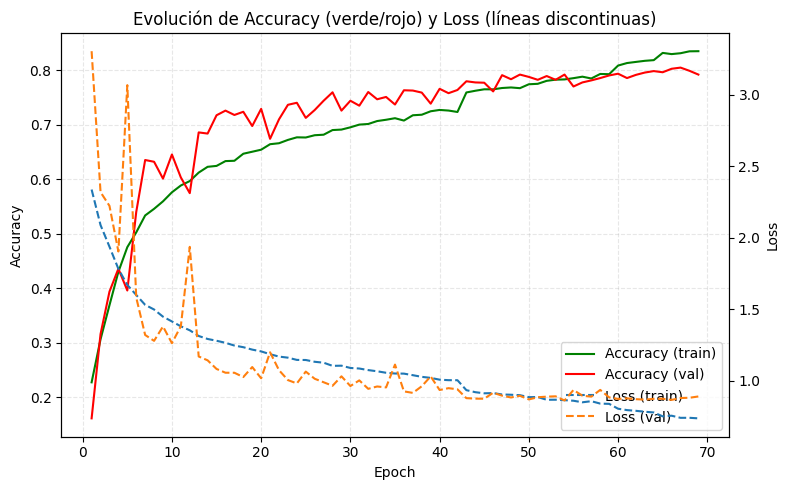

In [46]:
import matplotlib.pyplot as plt

hist = h.history

# Detectar las claves de accuracy (train/val)
acc_key = next((k for k in hist if 'acc' in k and not k.startswith('val_')), None)
val_acc_key = next((k for k in hist if k.startswith('val_') and 'acc' in k), None)

# Rango de épocas robusto
num_epochs = len(next(iter(hist.values())))
epochs_range = range(1, num_epochs + 1)

fig, ax1 = plt.subplots(figsize=(8, 5))

# --- Accuracy (eje izquierdo) ---
lines = []
labels = []

if acc_key:
    l1, = ax1.plot(epochs_range, hist[acc_key], color='green', label=f'{acc_key}')
    lines.append(l1); labels.append('Accuracy (train)')
if val_acc_key:
    l2, = ax1.plot(epochs_range, hist[val_acc_key], color='red', label=f'{val_acc_key}')
    lines.append(l2); labels.append('Accuracy (val)')

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.grid(True, which='both', linestyle='--', alpha=0.3)

# --- Loss (eje derecho) ---
ax2 = ax1.twinx()
l3, = ax2.plot(epochs_range, hist['loss'], linestyle='--', label='loss')
lines.append(l3); labels.append('Loss (train)')

if 'val_loss' in hist:
    l4, = ax2.plot(epochs_range, hist['val_loss'], linestyle='--', label='val_loss')
    lines.append(l4); labels.append('Loss (val)')

ax2.set_ylabel("Loss")

# Leyenda combinada
ax1.legend(lines, labels, loc='best')

plt.title("Evolución de Accuracy (verde/rojo) y Loss (líneas discontinuas)")
plt.tight_layout()
plt.show()



## Validation


In [47]:
import numpy as np

def tta_predict_single(model, x_hw3):
    """
    x_hw3: imagen YA preprocesada (H=W=IMG_SIZE, [0,1], float32), shape (H,W,3)
    Devuelve el vector de probabilidades promediado sobre varias vistas.
    """
    Xs = []
    for k in [0, 1, 2, 3]:
            xr = np.rot90(x_hw3, k).copy()
            Xs.append(xr)               # rot k
            Xs.append(xr[:, ::-1, :])   # rot k + flip H

    Xb = np.stack(Xs, axis=0)           # (V,H,W,3)
    p = model.predict(Xb, verbose=0)    # (V,C)
    return p.mean(axis=0)               # (C,)

In [48]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

def draw_confusion_matrix(cm, categories):
    # Draw confusion matrix
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.colormaps['Blues'])
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=list(categories.values()), yticklabels=list(categories.values()), ylabel='Annotation', xlabel='Prediction')
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # Loop over data dimensions and create text annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], '.2f'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=int(20-pow(len(categories), 0.5)))
    fig.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import tensorflow
model.load_weights('cnn_from_scratch.keras')  # o el checkpoint que uses
y_true, y_pred = [], []

for (filename, obj_pred) in objs_valid:
    # Cargar imagen completa
    full = load_geoimage(filename)
    H, W = full.shape[:2]

    # Recorte del bbox con un margen (igual que en el generador)
    x1, y1, x2, y2 = map(int, obj_pred.bb)
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(W, x2), min(H, y2)
    crop = full[y1:y2, x1:x2]
    crop = crop_with_margin(full, obj_pred.bb, 0.15)
    x = preprocess_image(crop)
    x = np.expand_dims(x, 0)

    # Predicción del modelo
    p_avg = tta_predict_single(model, x[0])
    pred_idx = int(np.argmax(p_avg))
    y_pred.append(pred_idx)

    # Etiqueta real
    true_idx = cat_to_idx(obj_pred.category)
    assert true_idx is not None, f"Clase no mapeada: {obj_pred.category}"
    y_true.append(true_idx)


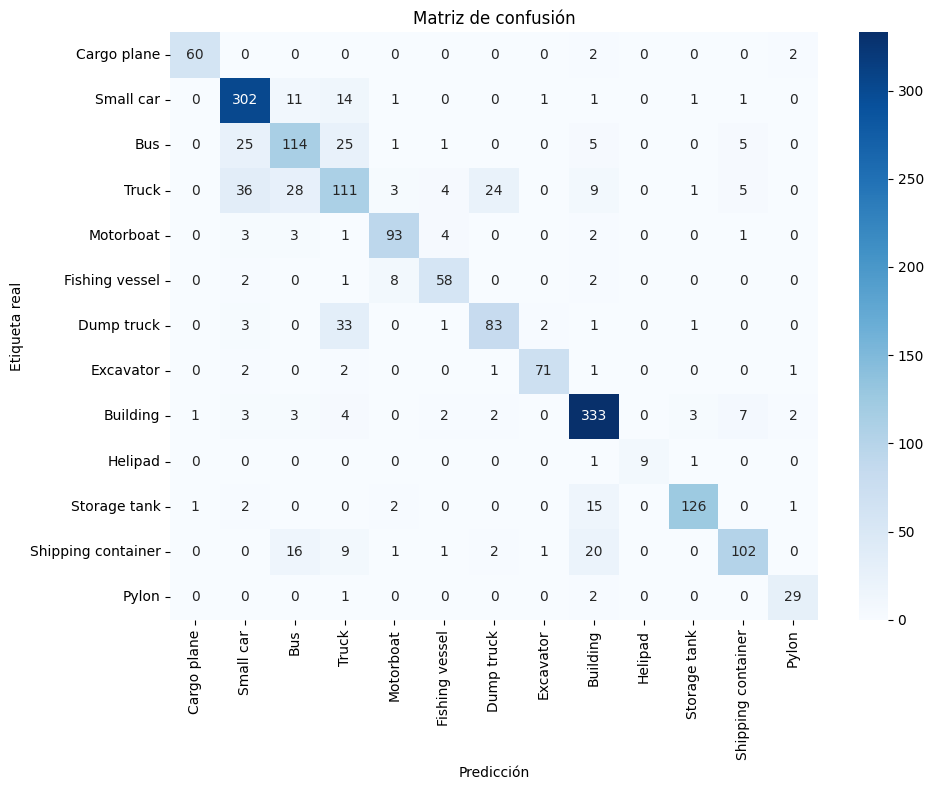

In [50]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels = list(range(len(class_names)))  # 0..N-1
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()


In [51]:
import numpy as np

# Compute the accuracy
correct_samples_class = np.diag(cm).astype(float)
total_samples_class = np.sum(cm, axis=1).astype(float)
total_predicts_class = np.sum(cm, axis=0).astype(float)
print('Mean Accuracy: %.3f%%' % (np.sum(correct_samples_class) / np.sum(total_samples_class) * 100))
acc = correct_samples_class / np.maximum(total_samples_class, np.finfo(np.float64).eps)
print('Mean Recall: %.3f%%' % (acc.mean() * 100))
acc = correct_samples_class / np.maximum(total_predicts_class, np.finfo(np.float64).eps)
print('Mean Precision: %.3f%%' % (acc.mean() * 100))
for idx in range(len(categories)):
    # True/False Positives (TP/FP) refer to the number of predicted positives that were correct/incorrect.
    # True/False Negatives (TN/FN) refer to the number of predicted negatives that were correct/incorrect.
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    # True Positive Rate: proportion of real positive cases that were correctly predicted as positive.
    recall = tp / np.maximum(tp+fn, np.finfo(np.float64).eps)
    # Precision: proportion of predicted positive cases that were truly real positives.
    precision = tp / np.maximum(tp+fp, np.finfo(np.float64).eps)
    # True Negative Rate: proportion of real negative cases that were correctly predicted as negative.
    specificity = tn / np.maximum(tn+fp, np.finfo(np.float64).eps)
    # Dice coefficient refers to two times the intersection of two sets divided by the sum of their areas.
    # Dice = 2 |A∩B| / (|A|+|B|) = 2 TP / (2 TP + FP + FN)
    f1_score = 2 * ((precision * recall) / np.maximum(precision+recall, np.finfo(np.float64).eps))
    print('> %s: Recall: %.3f%% Precision: %.3f%% Specificity: %.3f%% Dice: %.3f%%' % (list(categories.values())[idx], recall*100, precision*100, specificity*100, f1_score*100))

Mean Accuracy: 79.520%
Mean Recall: 80.311%
Mean Precision: 83.018%
> Cargo plane: Recall: 93.750% Precision: 96.774% Specificity: 99.890% Dice: 95.238%
> Small car: Recall: 90.964% Precision: 79.894% Specificity: 95.075% Dice: 85.070%
> Bus: Recall: 64.773% Precision: 65.143% Specificity: 96.410% Dice: 64.957%
> Truck: Recall: 50.226% Precision: 55.224% Specificity: 94.559% Dice: 52.607%
> Motorboat: Recall: 86.916% Precision: 85.321% Specificity: 99.095% Dice: 86.111%
> Fishing vessel: Recall: 81.690% Precision: 81.690% Specificity: 99.279% Dice: 81.690%
> Dump truck: Recall: 66.935% Precision: 74.107% Specificity: 98.344% Dice: 70.339%
> Excavator: Recall: 91.026% Precision: 94.667% Specificity: 99.777% Dice: 92.810%
> Building: Recall: 92.500% Precision: 84.518% Specificity: 95.974% Dice: 88.329%
> Helipad: Recall: 81.818% Precision: 100.000% Specificity: 100.000% Dice: 90.000%
> Storage tank: Recall: 85.714% Precision: 94.737% Specificity: 99.595% Dice: 90.000%
> Shipping containe

#### Testing
Try to improve the results provided in the competition.

In [52]:
import os
import numpy as np

anns = []
for (dirpath, dirnames, filenames) in os.walk('Práctica/xview_recognition/xview_test'):
    for filename in filenames:
        image_rel = os.path.relpath(dirpath, 'Práctica/xview_recognition')
        image = GenericImage(os.path.join(image_rel, filename))
        image.tile = np.array([0, 0, 224, 224])
        obj = GenericObject()
        obj.bb = (0, 0, 224, 224)
        obj.category = dirpath[dirpath.rfind('/')+1:]
        image.add_object(obj)
        anns.append(image)
print('Number of testing images: ' + str(len(anns)))

Number of testing images: 2365


In [ ]:
import os
import numpy as np

model.load_weights('cnn_from_scratch.keras')
predictions_data = {"images": {}, "annotations": {}}

for idx, ann in enumerate(anns):
    filename = os.path.basename(ann.filename) 
    image_data = {
        "image_id": filename,
        "filename": ann.filename,
        "width": int(ann.tile[2]),
        "height": int(ann.tile[3])
    }
    predictions_data["images"][idx] = image_data

    # Load image
    image = load_geoimage(ann.filename)
    image = preprocess_image(image)

    for obj_pred in ann.objects:
        crop = crop_with_margin(image, obj_pred.bb, margin=0.15)
        predictions = tta_predict_single(model, crop)

        pred_category = int(np.argmax(predictions)) 
        pred_score = np.max(predictions)
        annotation_data = {
            "image_id": filename,
            "category_id": pred_category,
            "bbox": [int(x) for x in obj_pred.bb]
        }
        predictions_data["annotations"][idx] = annotation_data


In [54]:
with open("prediction_cnn.json", "w") as outfile:
    json.dump(predictions_data, outfile)